Problem Statement:


You have been provided purchase data for various customers across a vertical. You need to
apply your learnings from Data Manipulation, Data Visualization, and statistical analysis to come
up with actionable insights about the data.


Tasks To Be Performed:

1. Perform a Detailed EDA for the Data with inferences from each of the actions.
2. Using Statistical Analysis, find out statistical evidence for the following:
-  It was observed that the average purchase made by the Men of the age 18-25
was 10000. Is it still the same?
- It was observed that the percentage of women of the age that spend more than
10000 was 35%. Is it still the same?
- Is the average purchase made by men and women of the age 18-25 same?
- Is the percentage of men who have spent more than 10000 the same for the
ages 18-25 and 26-35?

In [1]:
# import libraries
# upload and read the data
# EDA ---> understanding your data(exploratory data analysis)
# gathering insights
# conclusion

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data=pd.read_csv("train (4).csv")

In [15]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [16]:
data['Age'].value_counts()

26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: Age, dtype: int64

In [5]:
#eda
# shape, info, isnull, describe, dtypes, columns, head, tail,....

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [7]:
# 6 insights --> column names, how many rows n columns we have, range of index, datatypes, null values

In [10]:
# label encoding (object ---> int)
from sklearn.preprocessing import LabelEncoder

In [11]:
# object for LE
le=LabelEncoder()

In [17]:
data['User_ID']=le.fit_transform(data['User_ID'])
data['Product_ID']=le.fit_transform(data['Product_ID'])
data['Gender']=le.fit_transform(data['Gender'])
data['Age']=le.fit_transform(data['Age'])
data['City_Category']=le.fit_transform(data['City_Category'])

for i in data.columns:
  if i.dtype=='object':
    data[i]=le.data[i]

In [18]:
data['Age'].value_counts()

2    219587
3    110013
1     99660
4     45701
5     38501
6     21504
0     15102
Name: Age, dtype: int64

In [20]:
data['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [21]:
data['Stay_In_Current_City_Years']=data['Stay_In_Current_City_Years'].replace("4+","4")

In [22]:
data['Stay_In_Current_City_Years'].unique()

array(['2', '4', '3', '1', '0'], dtype=object)

In [23]:
data['Stay_In_Current_City_Years']=data['Stay_In_Current_City_Years'].astype(int)

In [24]:
data['Stay_In_Current_City_Years'].dtype

dtype('int64')

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  int64  
 2   Gender                      550068 non-null  int64  
 3   Age                         550068 non-null  int64  
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  int64  
 6   Stay_In_Current_City_Years  550068 non-null  int64  
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 50.4 MB


In [26]:
data.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [27]:
data=data.dropna()

In [28]:
data.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [29]:
data.shape

(166821, 12)

In [30]:
data['Gender'].value_counts()

1    129227
0     37594
Name: Gender, dtype: int64

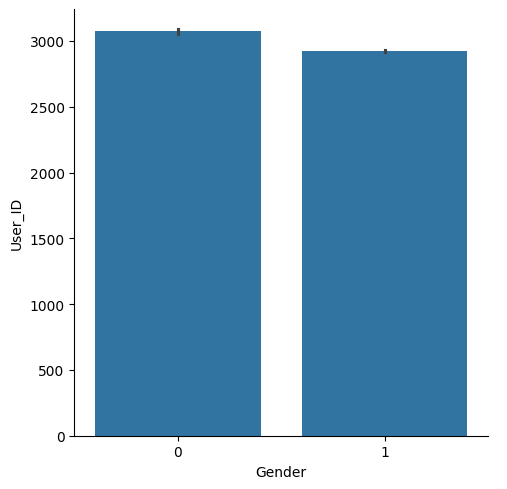

In [31]:
sns.catplot(data=data,x='Gender',y='User_ID',kind='bar')

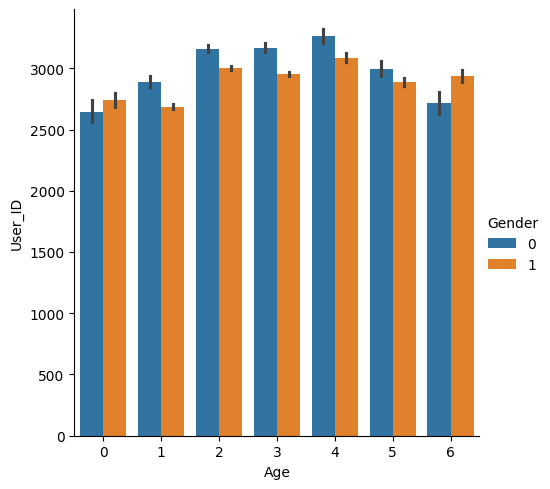

In [33]:
sns.catplot(data=data,x='Age',y='User_ID',hue='Gender',kind='bar')

stats

In [34]:
#It was observed that the average purchase made by the Men of the age 18-25 was 10000. Is it still the same?

In [35]:
new_data=data.loc[(data['Age']==1) & data['Gender']==1]

In [37]:
sample_size=1000

In [42]:
pos_mean=10000

In [38]:
sample=new_data.sample(sample_size,random_state=0)

In [36]:
new_data.shape

(24239, 12)

In [39]:
sample_mean=sample['Purchase'].mean()

In [40]:
print(sample_mean)

11806.467


In [41]:
from scipy.stats import ttest_1samp

In [43]:
t_stats,p_value=ttest_1samp(sample['Purchase'],pos_mean)

In [44]:
p_value

1.4097545140748985e-27

It was observed that the percentage of women of the age that spend more than 10000 was 35%. Is it still the same?

In [45]:
# null--> 35%
# alt --> not 35%

In [48]:
df=data.loc[(data['Purchase']>10000)]

In [49]:
df.shape

(102477, 12)

In [52]:
count=df['Gender'].value_counts()[0]

In [53]:
count

21124

In [54]:
# numbr of observations
nob=len(data['Gender'])
p0=0.35

In [55]:
from statsmodels.stats.proportion import proportions_ztest

In [56]:
z_stats,p_val=proportions_ztest(count=count,nobs=nob, value=p0,alternative="two-sided")

In [58]:
z_stats

-274.3429925643262

In [59]:
p_val

0.0